This is an older version in which I set the raw next_close as my target. Have since altered my target to next_close_pct_change. 

In [1]:
%%time

# Import libraries
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# Load dataset
df_model = pd.read_csv(
    'transformed_daily_data/daily_data_5y_30k_features1.csv'
)

# Prepare dataset

# Ensure datetime formatting
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

# Sort dataset
df_model = df_model.sort_values(
    ['ticker', 'timestamp']
).copy()


# Create target (next day closing price)
df_model['next_close'] = (
    df_model.groupby('ticker')['close'].shift(-1)
)

# Remove final row per ticker for which next_close does not exist)
df_model = df_model[
    df_model['next_close'].notna()
].copy()



# Train/test split

# Train on 2021-2024 data
train_df = df_model[
    (df_model['timestamp'] >= '2021-01-01') &
    (df_model['timestamp'] < '2025-01-01')
].copy()

# Test on 2025 data
test_df = df_model[
    (df_model['timestamp'] >= '2025-01-01') &
    (df_model['timestamp'] < '2026-01-01')
].copy()


# Select features
exclude_cols = [
    'timestamp',
    'ticker',
    'next_close'
]

feature_cols = [
    col for col in df_model.columns
    if col not in exclude_cols
]


X_train = train_df[feature_cols]
y_train = train_df['next_close']

X_test = test_df[feature_cols]
y_test = test_df['next_close']


# Define model
model = RandomForestRegressor(
    n_estimators=200,
    max_features=1,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


# Train model
model.fit(X_train, y_train)


# Get predictinos
y_test_pred = model.predict(X_test)


# Define evaluation metrics
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print("\n===== REGRESSION METRICS =====")

print(f"MAE:    {mae:.4f}")
print(f"MSE:    {mse:.4f}")
print(f"RMSE:   {rmse:.4f}")
print(f"MedAE:  {medae:.4f}")
print(f"R²:     {r2:.4f}")


===== REGRESSION METRICS =====
MAE:    2.4252
MSE:    98.6126
RMSE:   9.9304
MedAE:  0.7816
R²:     0.9952
CPU times: user 2min 12s, sys: 12.4 s, total: 2min 24s
Wall time: 27.4 s


In [2]:
results_df = test_df.copy()
results_df['pred_next_close'] = (y_test_pred).round(2)
results_df['pred_error'] = results_df['pred_next_close'] - results_df['next_close']
results_df['abs_pred_error'] = results_df['pred_error'].abs()

In [3]:
results_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,MACD_signal,MACD_hist,rolling_volatility,close_lag1,close_lag2,return_lag1,next_close,pred_next_close,pred_error,abs_pred_error
872,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,-1.349609,-0.075438,0.014294,37.78,37.15,0.016958,35.71,38.32,2.61,2.61
873,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,-1.387444,-0.151340,0.029454,37.99,37.78,0.005558,36.49,36.01,-0.48,0.48
874,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,-1.419583,-0.128553,0.033236,35.71,37.99,-0.060016,36.24,36.26,0.02,0.02
875,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,-1.447219,-0.110544,0.032951,36.49,35.71,0.021843,36.00,36.13,0.13,0.13
876,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,-1.471115,-0.095584,0.030724,36.24,36.49,-0.006851,35.91,35.91,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478297,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,-1.891613,1.082639,0.008772,123.54,123.78,-0.001939,126.23,125.59,-0.64,0.64
478298,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,-1.604182,1.149727,0.008752,125.49,123.54,0.015784,125.98,125.86,-0.12,0.12
478299,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,-1.321637,1.130177,0.008154,126.23,125.49,0.005897,126.41,125.91,-0.50,0.50
478300,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,-1.047095,1.098168,0.007307,125.98,126.23,-0.001981,125.82,126.49,0.67,0.67


In [4]:
results_df.to_csv('models_daily_results/daily_raw_target_preds_RFR.csv', index=False)

In [3]:
daily_prediction_summary = (
    results_df
    .groupby('timestamp')
    .agg(
        stocks_predicted=('ticker', 'count'),

        actual_next_close_mean=('next_close', 'mean'),
        predicted_next_close_mean=('pred_next_close', 'mean'),

        pred_error_mean=('pred_error', 'mean'),
        pred_error_median=('pred_error', 'median'),

        abs_pred_error_mean=('abs_pred_error', 'mean'),
        abs_pred_error_median=('abs_pred_error', 'median'),

        pred_error_std=('pred_error', 'std'),

        max_overprediction=('pred_error', 'max'),
        max_underprediction=('pred_error', 'min')
    )
    .reset_index()
)

daily_prediction_summary

,timestamp,stocks_predicted,actual_next_close_mean,predicted_next_close_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction
0,2025-01-02,397,117.199768,115.716851,-1.482917,-0.52,1.960181,0.70,3.925307,23.370,-37.08
1,2025-01-03,397,117.861713,116.799647,-1.062065,-0.22,2.261280,0.85,5.561355,20.130,-56.67
2,2025-01-06,397,116.922477,117.503904,0.581427,0.24,1.837901,0.67,3.841582,18.805,-27.08
3,2025-01-07,397,117.187602,116.762267,-0.425335,0.06,1.472952,0.68,3.029833,11.610,-29.58
4,2025-01-08,397,115.575619,116.820806,1.245187,0.74,2.181157,1.06,3.931158,22.650,-44.62
...,...,...,...,...,...,...,...,...,...,...,...
245,2025-12-24,397,134.973287,133.458791,-1.514496,-0.04,2.283086,0.40,20.355561,9.010,-375.69
246,2025-12-26,397,134.335798,133.636071,-0.699728,0.18,2.361632,0.51,18.312063,17.470,-338.10
247,2025-12-29,397,133.968405,133.233526,-0.734879,0.21,2.091066,0.50,18.073616,10.810,-338.61
248,2025-12-30,397,132.768325,132.979572,0.211247,0.65,2.603539,0.71,17.694014,16.390,-327.63


# Is median a better measure of this?

In [ ]:
daily_prediction_summary = (
    results_df
    .groupby('timestamp')
    .agg(
        stocks_predicted=('ticker', 'count'),

        actual_next_close_mean=('next_close', 'mean'),
        predicted_next_close_mean=('pred_next_close', 'mean'),

        pred_error_mean=('pred_error', 'mean'),
        pred_error_median=('pred_error', 'median'),

        abs_pred_error_mean=('abs_pred_error', 'mean'),
        abs_pred_error_median=('abs_pred_error', 'median'),

        pred_error_std=('pred_error', 'std'),

        max_overprediction=('pred_error', 'max'),
        max_underprediction=('pred_error', 'min')
    )
    .reset_index()
)

daily_prediction_summary

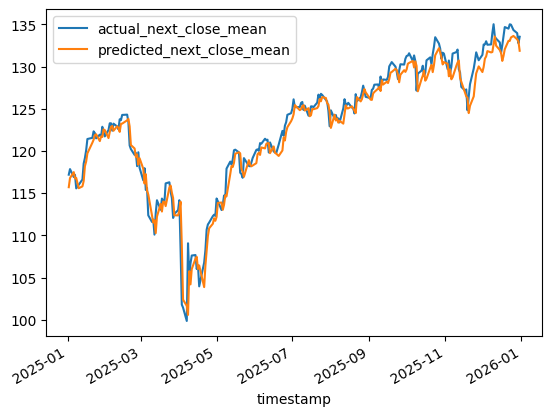

In [4]:
daily_prediction_summary.set_index('timestamp')[['actual_next_close_mean', 'predicted_next_close_mean']].plot()
plt.show()